In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import joblib

In [2]:
# Setting up visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Uploading data
df = pd.read_csv('../../data/raw/goodreads_data.csv')

In [4]:
# Initial inspection
print('Dataset size', df.shape)
print('\nInformation about the dataset: ')
df.info()

Dataset size (10000, 8)

Information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   10000 non-null  int64  
 1   Book         10000 non-null  object 
 2   Author       10000 non-null  object 
 3   Description  9923 non-null   object 
 4   Genres       10000 non-null  object 
 5   Avg_Rating   10000 non-null  float64
 6   Num_Ratings  10000 non-null  object 
 7   URL          10000 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [5]:
df = df.drop(['Unnamed: 0', 'Num_Ratings', 'URL'], axis=1)
print('\nThe first 5 lines: ')
df.head()


The first 5 lines: 


,Book,Author,Description,Genres,Avg_Rating
0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47
2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28
3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18
4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98


In [6]:
print('\nStatistics of numerical features: ')
df.describe()


Statistics of numerical features: 


,Avg_Rating
count,10000.000000
mean,4.068577
std,0.335359
min,0.000000
25%,3.880000
50%,4.080000
75%,4.260000
max,5.000000


In [7]:
print('\nMissing values: ')
df.isnull().sum()


Missing values: 


Book            0
Author          0
Description    77
Genres          0
Avg_Rating      0
dtype: int64

In [8]:
# Genre analysis
def to_list(x):
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return val
        else:
            return [val]
    except:
        return [x]

df['Genres'] = df['Genres'].apply(to_list)
all_genres = df.explode('Genres')
genre_counts = all_genres['Genres'].value_counts()
print(genre_counts)

Genres
Fiction                    5700
Nonfiction                 2330
Fantasy                    2195
Classics                   2123
Romance                    1558
                           ... 
Comix                         1
Wicca                         1
Witchcraft                    1
Science Fiction Romance       1
New Adult Romance             1
Name: count, Length: 617, dtype: int64


In [9]:
# Visualization of genre distribution
plt.figure(figsize=(200,50))
genre_counts.plot(kind='bar')
plt.title('Distribution of books by genre')
plt.xlabel('Genre')
plt.ylabel('Number of books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../data/processed/genre_distribution.png')
plt.show()

In [10]:
# Analysis of the most frequent genres (top 10)
top_genres = genre_counts.head(10)
print("Top 10 genres:")
print(top_genres)

Top 10 genres:
Genres
Fiction               5700
Nonfiction            2330
Fantasy               2195
Classics              2123
Romance               1558
Young Adult           1522
Historical Fiction    1481
Mystery               1357
Contemporary          1302
Audiobook             1242
Name: count, dtype: int64


In [11]:
# Filling in the missing values
print("Missing values before processing:")
print(df.isnull().sum())

Missing values before processing:
Book            0
Author          0
Description    77
Genres          0
Avg_Rating      0
dtype: int64


In [12]:
# Filling in gaps in
df['Description'] = df['Description'].fillna('')

print("Missing values after processing:")
print(df.isnull().sum())

Missing values after processing:
Book           0
Author         0
Description    0
Genres         0
Avg_Rating     0
dtype: int64


In [13]:
# Creating new features
df['Title_Length'] = df['Book'].apply(len)
df['Description_Length'] = df['Description'].apply(len)

In [14]:
# Analysis of new features
numeric_features = ['Title_Length', 'Description_Length', 'Avg_Rating']
df[numeric_features].describe()

,Title_Length,Description_Length,Avg_Rating
count,10000.000000,10000.000000,10000.000000
mean,33.061000,948.774600,4.068577
std,22.281013,623.812499,0.335359
min,2.000000,0.000000,0.000000
25%,17.000000,578.000000,3.880000
50%,28.000000,852.000000,4.080000
75%,43.000000,1180.250000,4.260000
max,231.000000,24732.000000,5.000000


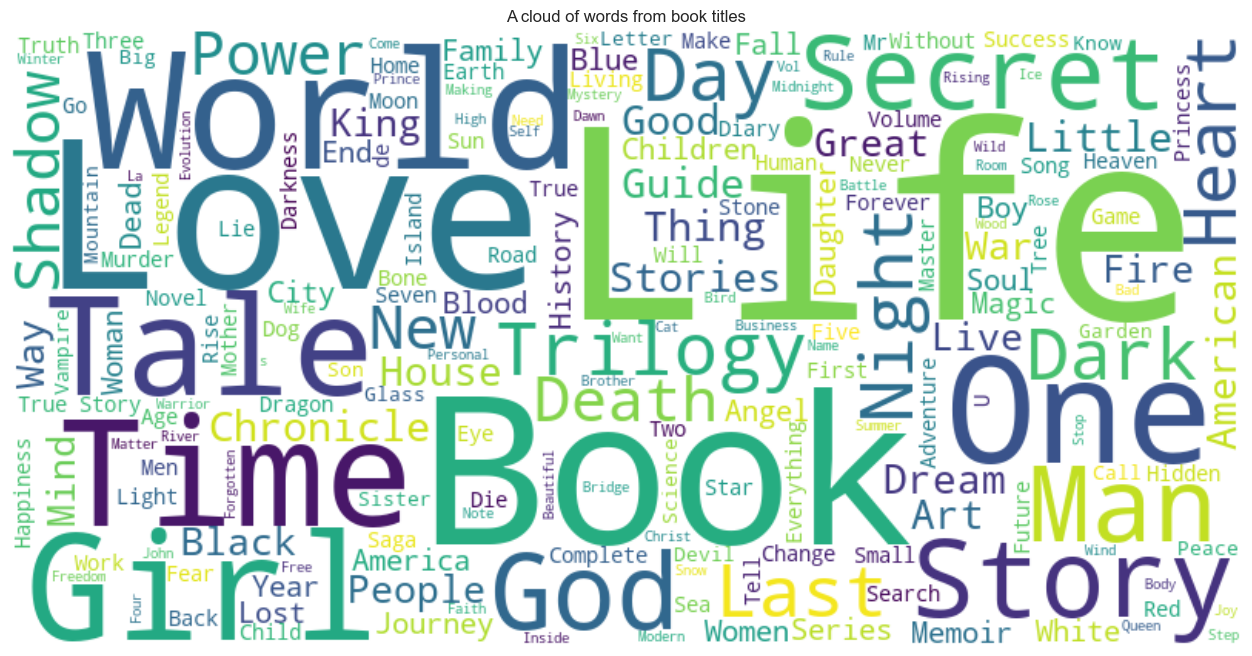

In [15]:
# Analysis of the most frequent words in names
title_text = " ".join(df['Book'].dropna().values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(title_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('A cloud of words from book titles')
plt.savefig('../../data/processed/title_wordcloud.png')
plt.show()

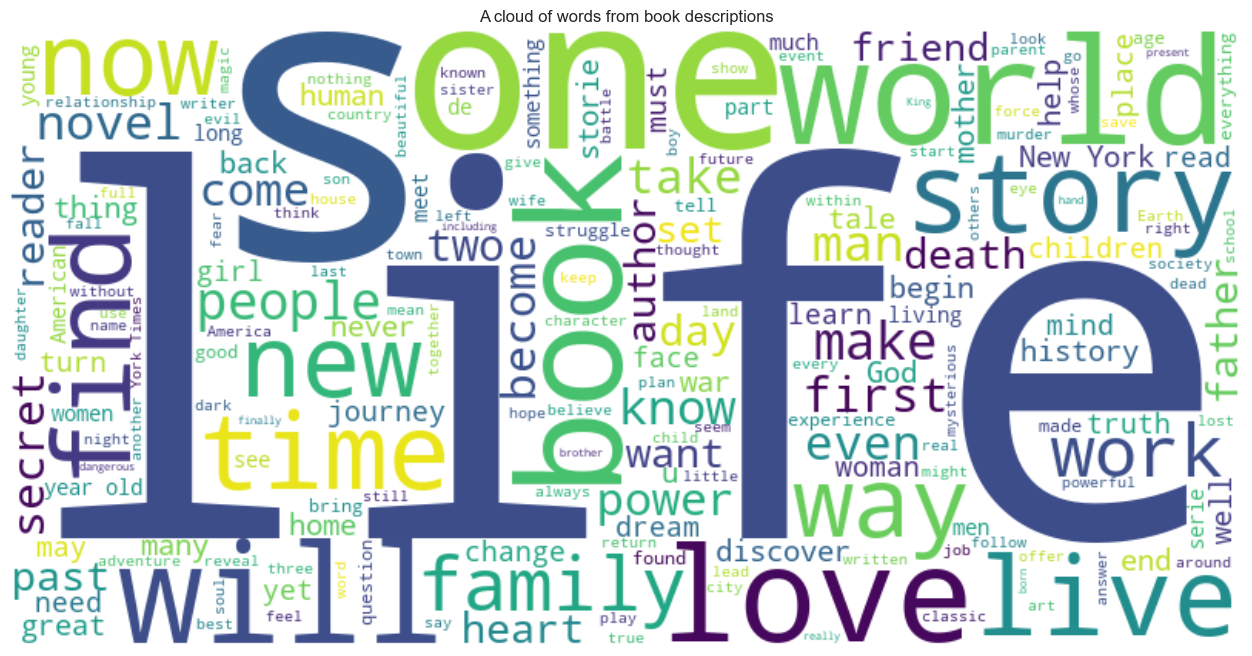

In [16]:
# Analysis of the most frequent words in descriptions
description_text = " ".join(df['Description'].dropna().values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(description_text)

plt.figure(figsize=(16,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('A cloud of words from book descriptions')
plt.savefig('../../data/processed/description_wordcloud.png')
plt.show()

In [17]:
# Balancing the data - let's leave only genres with a sufficient number of examples
min_samples = 100 # the minimum number of books in the genre
all_genres = df.explode('Genres')
genre_counts = all_genres['Genres'].value_counts()
valid_genres = set(genre_counts[genre_counts >= min_samples].index)
df['Genres'] = df['Genres'].apply(lambda genres: [g for g in genres if g in valid_genres])
df_balanced = df[df['Genres'].map(len) > 0].copy()

all_genres = df_balanced.explode('Genres')
print(f"Dataset size after balancing: {df_balanced.shape}")
print("Genre distribution after balancing:")
print(all_genres['Genres'].value_counts())

Dataset size after balancing: (8987, 7)
Genre distribution after balancing:
Genres
Fiction             5700
Nonfiction          2330
Fantasy             2195
Classics            2123
Romance             1558
                    ... 
19th Century         107
Health               107
Post Apocalyptic     104
Education            101
American History     100
Name: count, Length: 96, dtype: int64


In [20]:
# Preparing data for ML
# Encoding genres
multi_label_binarizer = MultiLabelBinarizer()
genre_encoded_array = multi_label_binarizer.fit_transform(df_balanced['Genres'])
genre_encoded_df = pd.DataFrame(genre_encoded_array, columns=multi_label_binarizer.classes_, index=df_balanced.index)
df_balanced = pd.concat([df_balanced, genre_encoded_df], axis=1)
df_balanced.head()

,Book,Author,Description,Genres,Avg_Rating,Title_Length,Description_Length,19th Century,20th Century,Action,...,Suspense,Teen,Theatre,Thriller,Travel,Urban Fantasy,Vampires,War,World War II,Young Adult
0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"[Classics, Fiction, Historical Fiction, School...",4.27,21,818,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"[Fantasy, Fiction, Young Adult, Magic, Childre...",4.47,59,227,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","[Classics, Fiction, Romance, Historical Fictio...",4.28,19,648,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"[Classics, Nonfiction, History, Biography, Mem...",4.18,25,1041,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"[Classics, Fiction, Dystopia, Fantasy, Politic...",3.98,11,780,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
# Saving the MultiLabelBinarizer for later use
joblib.dump(multi_label_binarizer, '../../data/models/label_encoder.pkl')

['../../data/models/label_encoder.pkl']

In [26]:
# Separation into attributes and target variable
X = df_balanced[['Book', 'Author', 'Description', 'Title_Length', 'Description_Length', 'Avg_Rating']]
y = genre_encoded_df

In [28]:
# Separation into training and test samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training sample size: {X_train.shape}")
print(f"Test sample size: {X_test.shape}")

Training sample size: (7189, 6)
Test sample size: (1798, 6)


In [29]:
# Saving processed data
df_balanced.to_csv('../../data/processed/balanced_books.csv', index=False)

# Сохранение train/test split
joblib.dump({
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}, '../../data/processed/train_test_split.pkl')

print("Данные успешно сохранены!")

Данные успешно сохранены!
